In [1]:
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
import xarray as xr
from MHW_funcs import get_oisst_flag
from MHW_funcs import map_study_region
import matplotlib.pyplot as plt
import matplotlib.colors as mpcolors
from cmocean import cm as cmo
from cartopy import crs as ccrs
from cartopy import feature as cfeature 
import matplotlib.ticker as ticker


BOLD = "\033[1m"
RESET = "\033[0m"

## 1. Grab data
### 1.1. Select MHW

In [2]:
# Path to Crocolake
parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'

# path to heatwave csv
csv_path = '/home/jovyan/Marine-Heat-Waves/MHW_list.csv'

# open heatwave database and format
dfhw = pd.read_csv(csv_path)
dfhw.set_index('name',inplace=True)
date_cols = ['date_start','date_end']
dfhw[date_cols] = dfhw[date_cols].apply(pd.to_datetime)

# print heatwave options
print(f"{BOLD}Select from the following:{RESET} \n" + ", ".join(f"{n}: {idx}" for n, idx in enumerate(dfhw.index, start=0)))

# Choose a HW
hw = "NA 2023"

# Boundaries
lat0 = dfhw.loc[hw,'lat0'] 
lat1 = dfhw.loc[hw,'lat1'] 
lon0 = dfhw.loc[hw,'lon0'] 
lon1 = dfhw.loc[hw,'lon1'] 
z0 = 0
z1 = 500
date0 = dfhw.loc[hw,'date_start']
date1 = dfhw.loc[hw,'date_end']

Select from the following: 
0: Med2003, 1: Beng2001, 2: WA2011, 3: NWA2012, 4: WSA2014, 5: ECS2016, 6: AL2016, 7: NA2016, 8: NEP2015, 9: Tas2017, 10: Peru2017, 11: NA 2023, 12: SWPac2023


### 1.2. Get the data from the chosen MHW.

This method does deal with domains that cross 180<sup>o</sup> longitude.

In [3]:
# Setting up parquet schema
parquet_dir = '~/shared/go-bgc-2026/data/CrocoLake/BGC_ARGO/'
BGC_schema = pq.read_schema(parquet_dir+"_common_metadata")

# If lon crosses 180deg
if lon0 > lon1:
    # First half of meridional domain
    filters1 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<=",180),
                ("JULD",">",date0), ("JULD","<",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df1 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filter1)
    df1 = df1.read().to_pandas()
    df1 = pd.read_parquet(parquet_dir, schema=BGC_schema, schemafilters=filters1)

    # Second half of meridional domain
    filters2 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",-180), ("LONGITUDE","<=",lon2),
                ("JULD",">",date0), ("JULD","<",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df2 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filter2)
    df2 = df2.read().to_pandas()
    pd.read_parquet(parquet_dir,columns=columns,filters=filters1)

    # Combine domains
    df = pd.concat([df1, df2], ignore_index=True)

# If lon does NOT cross 180deg (normal case)
else:
    filters = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                ("JULD",">",date0), ("JULD","<",date1),
                ("PRES","<",z1), #("PRES",">",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters)
    df = df.read().to_pandas()



### 1.3. Select only the data you want

In [4]:
want_Oxygen = True
want_BBP = False
want_Turbidity = False
want_CP = False
want_Chla = False
want_CDOM = False
want_Nitrate = False
want_Bisulfide = False
want_pH = True
want_DownwellingIR = False
want_UpwellingIR = False
want_DownwellingPAR = False

In [5]:
base_info = ['PLATFORM_NUMBER', 'N_PROF', 'N_LEVELS', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD', 
             'PRES', 'TEMP', 'PSAL']
oxygen_info = ['DOXY_ADJUSTED', 'DOXY_ADJUSTED_QC', 'DOXY_ADJUSTED_ERROR']
bbp_info = ['BBP_ADJUSTED', 'BBP_ADJUSTED_QC', 'BBP_ADJUSTED_ERROR']
turbidity_info = ['TURBIDITY_ADJUSTED', 'TURBIDITY_ADJUSTED_QC', 'TURBIDITY_ADJUSTED_ERROR']
cp_info = ['CP_ADJUSTED', 'CP_ADJUSTED_QC', 'CP_ADJUSTED_ERROR']
chla_info = ['CHLA_ADJUSTED', 'CHLA_ADJUSTED_QC', 'CHLA_ADJUSTED_ERROR',
            'CHLA_FLUORESCENCE_ADJUSTED', 'CHLA_FLUORESCENCE_ADJUSTED_QC', 'CHLA_FLUORESCENCE_ADJUSTED_ERROR',
            ]
cdom_info = ['CDOM_ADJUSTED', 'CDOM_ADJUSTED_QC', 'CDOM_ADJUSTED_ERROR']
nitrate_info = ['NITRATE_ADJUSTED', 'NITRATE_ADJUSTED_QC', 'NITRATE_ADJUSTED_ERROR']
bisulfide_info = ['BISULFIDE_ADJUSTED', 'BISULFIDE_ADJUSTED_QC', 'BISULFIDE_ADJUSTED_ERROR']
ph_info = ['PH_IN_SITU_TOTAL_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED_QC', 'PH_IN_SITU_TOTAL_ADJUSTED_ERROR']
downirrad_info = ['DOWN_IRRADIANCE_ADJUSTED', 'DOWN_IRRADIANCE_ADJUSTED_QC', 'DOWN_IRRADIANCE_ADJUSTED_ERROR']
upirrad_info = ['UP_IRRADIANCE_ADJUSTED', 'UP_IRRADIANCE_ADJUSTED_QC', 'UP_IRRADIANCE_ADJUSTED_ERROR']
downpar_info = ['DOWNWELLING_PAR_ADJUSTED', 'DOWNWELLING_PAR_ADJUSTED_QC', 'DOWNWELLING_PAR_ADJUSTED_ERROR']

In [6]:
params = base_info

if want_Oxygen:
    params = params + oxygen_info
if want_BBP:
    params = params + bbp_info
if want_Turbidity:
    params = params + turbidity_info
if want_CP:
    params = params + cp_info
if want_Chla:
    params = params + chla_info
if want_CDOM:
    params = params + cdom_info
if want_Nitrate:
    params = params + nitrate_info
if want_Bisulfide:
    params = params + bisulfide_info
if want_pH:
    params = params + ph_info
if want_DownwellingIR:
    params = params + downirrad_info
if want_UpwellingIR:
    params = params + upirrad_info
if want_DownwellingPAR:
    params = params + downpar_info

print(f"You have selected the following parameters before QC: {params}")

df = df.loc[:,params]

You have selected the following parameters before QC: ['PLATFORM_NUMBER', 'N_PROF', 'N_LEVELS', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD', 'PRES', 'TEMP', 'PSAL', 'DOXY_ADJUSTED', 'DOXY_ADJUSTED_QC', 'DOXY_ADJUSTED_ERROR', 'PH_IN_SITU_TOTAL_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED_QC', 'PH_IN_SITU_TOTAL_ADJUSTED_ERROR']


### 1.4. Filter out bad data

#### [QC Flags](https://argo.ucsd.edu/data/how-to-use-argo-files/)
| QC flag | Meaning                                   | Real time comment                                                                                                                                                                                                                                                       | Delayed mode comment                                                                         |
|---------|-------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------|
| 0       | No QC performed                           | No QC performed                                                                                                                                                                                                                                                         | No QC performed                                                                              |
| 1       | Good data                                 | All real time QC tests passed                                                                                                                                                                                                                                           | The adjusted value is statistically consistent and a statistical error estimate is supplied. |
| 2       | Probably good data                        |                                                                                                                                                                                                                                                                         | Probably good                                                                                |
| 3       | Bad data that are potentially correctable | Test 15 or Test 16 or Test 17 failed and all other real-time QC  tests passed. These data are not to be used without scientific  correction. A flag ‘3’ may be assigned by an operator during additional  visual QC for bad data that may be corrected in delayed mode. | An adjustment has been applied, but the value may still be bad.                              |
| 4       | Bad data                                  | Data have failed one or more of the real-time QC tests, excluding  Test 16. A flag ‘4’ may be assigned by an operator during additional  visual QC for bad data that are not correctable.                                                                               | Bad data.  Not adjustable.                                                                   |
| 5       | Value changed                             | Value changed                                                                                                                                                                                                                                                           | Value changed                                                                                |
| 6       | Not currently used                        | Not currently used                                                                                                                                                                                                                                                      | Not currently used                                                                           |
| 7       | Not currently used                        | Not currently used                                                                                                                                                                                                                                                      | Not currently used                                                                           |
| 8       | Estimated                                 | Estimated value (interpolated, extrapolated or other estimation).                                                                                                                                                                                                       | Estimated value (interpolated, extrapolated or other estimation).                            |
| 9       | Missing value                             | Missing value                                                                                                                                                                                                                                                           | Missing value                                                                                |

In [7]:
qc_strings = [s for s in params if s.endswith("QC")]
bad_vals = [0,3,4,6,7,9]

In [8]:
for s in qc_strings:
    var = s.removesuffix("_QC")

    df.loc[df[s].isin(bad_vals), var] = np.nan

### 1.5. Some info on the data

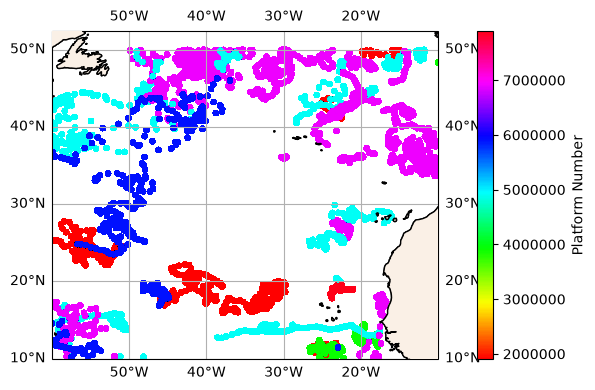

In [9]:
ax = map_study_region(ax_lims = [lon0, lon1, lat0, lat1])
im = ax.scatter(df['LONGITUDE'], df['LATITUDE'], 
                s = 10, c = df['PLATFORM_NUMBER'], cmap = 'hsv',
                transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, ax = ax)
cbar.ax.ticklabel_format(style='plain', axis='y')
cbar.set_label('Platform Number')

## 2. More data processing!
### 2.1. Adding month and year

In [10]:
df = df.assign(MONTH = [pd.Timestamp(ti).month for ti in df.loc[:,'JULD'].values])
df = df.assign(YEAR = [pd.Timestamp(ti).year for ti in df.loc[:,'JULD'].values])

### 2.2. Masking data for the MHW

[Function to flag data](https://github.com/go-bgc/Marine-Heat-Waves/blob/main/contributors/ellen/ellen_fxns.py) written by Ellen Park.

Mask of the North Atlantic 2023 heatwave created by Cassia Cai.

In [11]:
df_mhw = get_oisst_flag(df)

Openining : s3://uw-escience-scratch-prod/oisst/mhw_mask_north_atlantic_final.zarr


0  out of 608


100  out of 608


200  out of 608


300  out of 608


400  out of 608


500  out of 608


600  out of 608


In [12]:
df_mhw = df_mhw[df_mhw['mhw_mask'] == 1]

## 3. Make some preliminary plots
### 3.1. Temperature

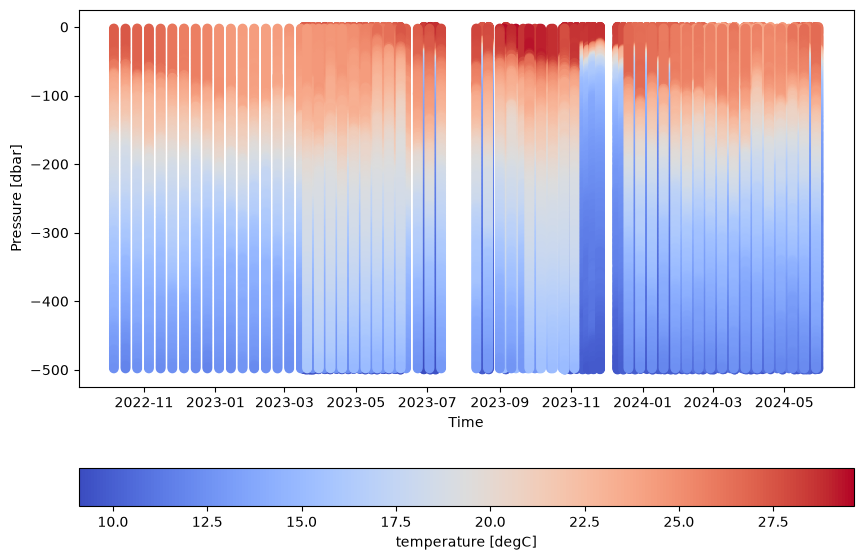

In [13]:
fig, ax = plt.subplots(figsize = [10,7])

x = df_mhw['JULD']
y = -df_mhw['PRES']
z = df_mhw['TEMP']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("temperature [degC]")

### 3.2. Oxygen

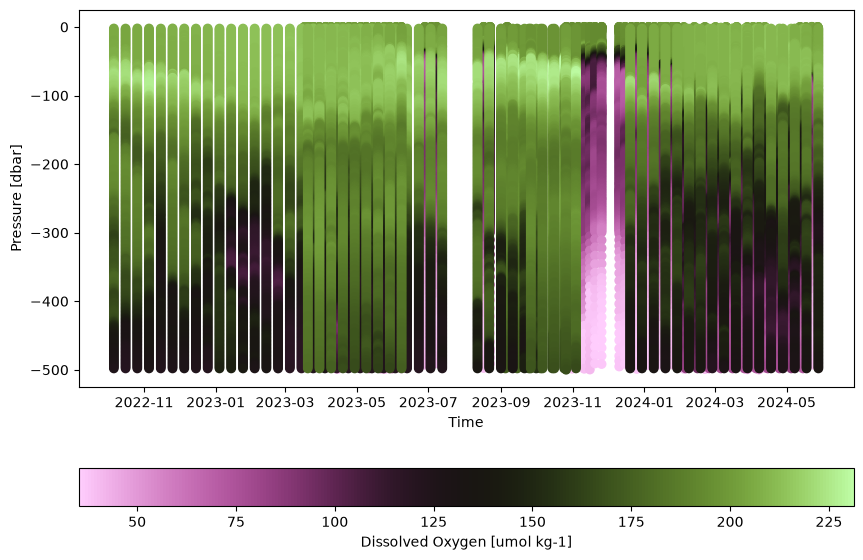

In [14]:
fig, ax = plt.subplots(figsize = [10,7])

x = df_mhw['JULD']
y = -df_mhw['PRES']
z = df_mhw['DOXY_ADJUSTED']

im = ax.scatter(x, y, c = z, cmap = 'vanimo')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("Dissolved Oxygen [umol kg-1]")

### 3.3. pH

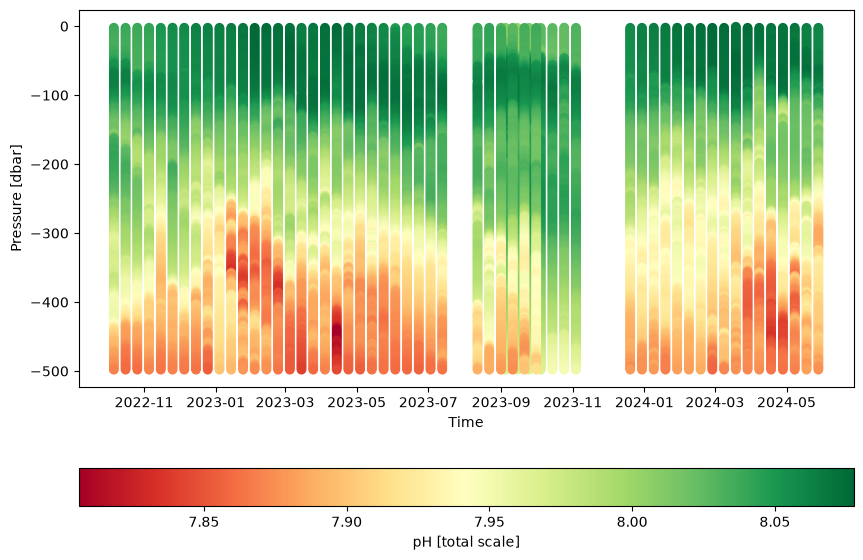

In [15]:
fig, ax = plt.subplots(figsize = [10,7])

x = df_mhw['JULD']
y = -df_mhw['PRES']
z = df_mhw['PH_IN_SITU_TOTAL_ADJUSTED']

im = ax.scatter(x, y, c = z, cmap = 'RdYlGn')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("pH [total scale]")